# Session 2 – When Models Become Too Simple or Too Complex

In machine learning you often hear terms like:

- **overfitting**
- **underfitting**
- **model complexity**

But what do these actually mean?

Where do they come from?  
Why do they happen?  
And how can we recognize them when training models?

In the previous session we used **simple visual datasets** to understand how models behave.  
We will continue with the same idea here.

Instead of formulas, we will use **visual experiments** to see how models change when we adjust their settings.

Many machine learning models have settings that control **how flexible the model is**.  
For example:

- polynomial degree in polynomial regression
- tree depth in decision trees
- number of neighbors in kNN
- regularization strength in regression
- parameters in SVM models

These settings control **how complex the model can become**.

In this notebook we explore a simple question:

**What happens when a model is too simple or too complex for the data?**

We will use visual experiments to observe three phenomena:

- **Underfitting** (model too simple)  
- **Good generalization**  
- **Overfitting** (model too complex)

Our goal is to build intuition for the **bias–variance tradeoff**.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Step 1 – Create a Simple Learning Problem

In real machine learning problems we never see the **true function**.

We only see **noisy observations**.

To simulate this situation we create:

- a **true function** (a sine wave)
- **observations** that contain noise

The model will only see the noisy observations.

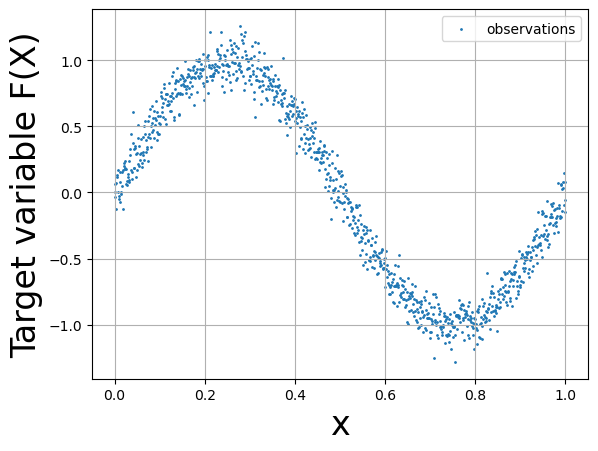

In [11]:
A= 1
OMEGA= 2* np.pi * 1
my_sine_func = lambda x: A *np.sin(OMEGA *x)


NOISE= .1 # controls data quality!
DATA_SIZE= 1000
Data_RANGE= 1 # leavfe it
x_train= np.linspace(0,Data_RANGE,DATA_SIZE)
y0=  my_sine_func(x_train)
noise= NOISE *np.random.randn(x_train.shape[0])
observation= y0+ noise
plt.scatter(x_train,observation, label='observations', s= 1)
plt.legend()
plt.xlabel('x', fontsize= 24)
plt.ylabel('Target variable F(X)', fontsize= 24)
plt.grid()


Text(0, 0.5, 'Target variable F(X)')

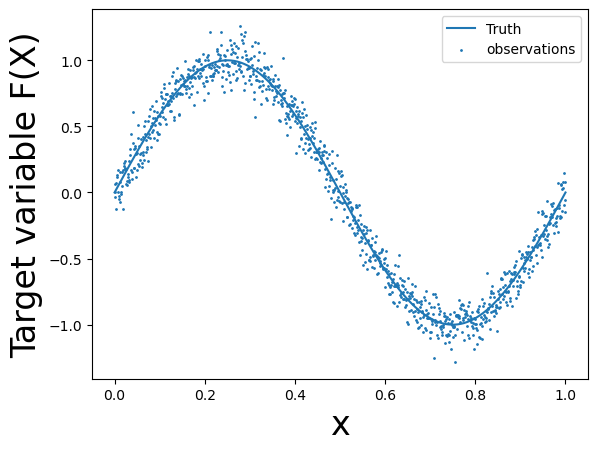

In [12]:
plt.plot(x_train,y0, label= 'Truth')
plt.scatter(x_train,observation, label='observations', s= 1)
plt.legend()
plt.xlabel('x', fontsize= 24)
plt.ylabel('Target variable F(X)', fontsize= 24)

The curve shows the **true function**.

The scattered points are the **observations with noise**.

In real ML problems we **do not know the true function**.

The model only sees the noisy observations and must **guess the underlying pattern**.

# Step 2 – Build a Model

A machine learning model is simply a **function**.

It takes an input `x` and produces a prediction `y`.

However, models also have **settings that control their flexibility**.

For polynomial regression this setting is:

**DEGREE**

A small degree creates a **simple model**.

A large degree creates a **very flexible model** that can bend and wiggle.

But flexibility can become dangerous:  
If the model becomes too flexible it may start fitting the **noise instead of the signal**.

### Model Complexity

Try changing the value of **DEGREE**.

Examples to try:

DEGREE = 1

DEGREE = 3

DEGREE = 7

DEGREE = 15


Questions to think about:

- When does the model become **too simple**?
- When does the model become **too flexible**?

In [16]:
DEGREE= 15 # controls how complex the model is, integer between 1-... (> 5 is large!)
model = make_pipeline(PolynomialFeatures(DEGREE), LinearRegression())

In [17]:
x_train= x_train.reshape(-1,1)
observation= observation.reshape(-1,1)
print(f"{x_train.shape},   {observation.shape}")
model.fit(x_train, observation) # train (tune  model parameters)

(1000, 1),   (1000, 1)


,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,15
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


# Step 3 – Testing the Model

The model was trained on data between:

0 and 1

Now we test it slightly **outside the training region**.

This helps us check whether the model learned the **true pattern** or simply memorized the training points.

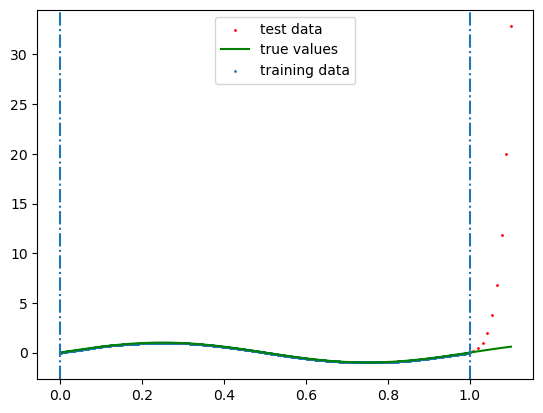

In [18]:
Test_span= 1.1

x_test= np.linspace(0,Test_span,97).reshape(-1,1)
y_pred= model.predict(x_test)
y_test=  my_sine_func(x_test)

plt.scatter(x_test,y_pred,s=1,c='red', label= 'test data')
plt.plot(x_test,y_test, c= 'green', label= 'true values')
plt.scatter(x_train,model.predict(x_train),s=1, label='training data')
plt.axvline(0, linestyle='-.')
plt.axvline(1, linestyle='-.')
plt.legend()


Look carefully at the curves.

Questions:

- Does the model follow the **true pattern**?
- Does it follow the **noise**?
- What happens outside the training region?

These behaviors illustrate **underfitting and overfitting**.

# Experiments

Try changing the following parameters:

- DATA_SIZE
- NOISE
- DEGREE

---
---

### Experiment 1 – Model Complexity

Try:

DEGREE = 1, 3, 7, 15

Which models:

- are too simple?
- follow the noise?



### Experiment 2 – Data Size

Try:

DATA_SIZE = 10, 50, 200

Does more data make the model more stable?



### Experiment 3 – Noise

Try:

NOISE = 0.01, 0.1, 0.5

Which models are most affected by noise?




### Experiment 4 – Extrapolation

The model was trained on data between **0 and 1**.

What happens when we test outside this region?

# Extra

# What Does "Polynomial Degree" Mean?

Polynomial regression creates new features:

x, x², x³, x⁴ ...

These allow the model to create **curved shapes**.

The plot below shows how polynomial basis functions look.

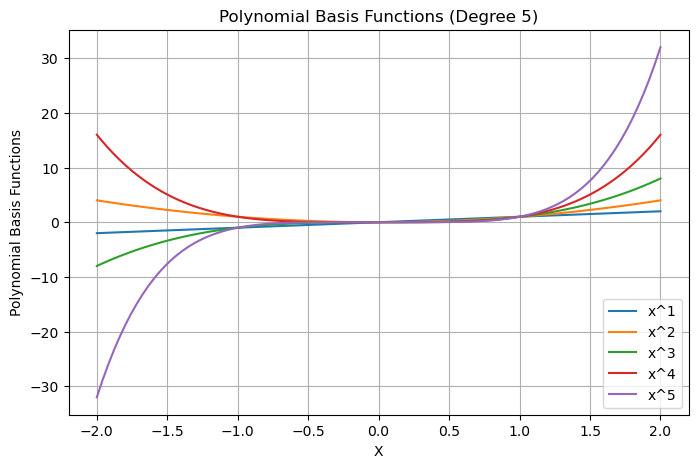

In [8]:
# Generate input values (X-axis)
X = np.linspace(-2, 2, 100).reshape(-1, 1)

def plot_polynomial_basis(degree):
    """Generate and plot polynomial basis functions up to a given degree."""
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)  # Create polynomial features

    plt.figure(figsize=(8, 5))

    for i in range(1, degree + 1):  # Ignore the bias term (column 0)
        plt.plot(X, X_poly[:, i], label=f"x^{i}")

    plt.xlabel("X")
    plt.ylabel("Polynomial Basis Functions")
    plt.title(f"Polynomial Basis Functions (Degree {degree})")
    plt.legend()
    plt.grid()
    plt.show()


plot_polynomial_basis(5)
